<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/Proyecto%204/proyecto4_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea.png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Proyecto 4 - Clasificación de señales ECG</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>


# Importación de librerías y archivos

In [ ]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import neurokit2 as nk
import random

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Elección de arritmias

Se hace el cargue del dataframe *Diagnostics* para escoger las 4 arritmias que se emplearán para alimentar los modelos de clasificación de los puntos posteriores.

In [ ]:
data = pd.read_excel(r'C:\Programación\Bioseñales\Laboratorio y proyectos\proy3\Diagnostics.xlsx')
data

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10641,MUSE_20181222_204306_99000,SVT,NONE,80,FEMALE,196,73,168,284,513,258,244,32,177,261,319
10642,MUSE_20181222_204309_22000,SVT,NONE,81,FEMALE,162,81,162,294,482,110,-75,27,173,254,320
10643,MUSE_20181222_204310_31000,SVT,NONE,39,MALE,152,92,152,340,540,250,38,25,208,284,378
10644,MUSE_20181222_204312_58000,SVT,NONE,76,MALE,175,178,128,310,529,98,-83,29,205,269,360


In [ ]:
# 1. Prevalencia general de arritmias
arritmia_counts = data['Rhythm'].value_counts()
arritmia_counts=arritmia_counts.astype(str)
print("\nPrevalencia de arritmias:\n", arritmia_counts)


Prevalencia de arritmias:
 Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: object


Se seleccionaron las arritmias SB, SR, AFIB y ST por ser las más prevalentes en la base de datos. Estas arritmias prepresentan distintos mecanismos fisiológicos y alteraciones eléctricas del corazón: SB (bradicardia), SR (ritmo normal, para tener una referencia), ST (taquicardia) y AFIB (arritmia supraventricular irregular). Se descartaron las clases con menor número de registros para evitar desbalance y sobreajuste.

# 2. Extracción de los registros de la Derivación II

In [ ]:
dataSB_FileName = data.loc[lambda x: x["Rhythm"] == "SB", "FileName"].tolist()
dataAFIB_FileName = data.loc[lambda x: x["Rhythm"] == "AFIB", "FileName"].tolist()
dataSR_FileName = data.loc[lambda x: x["Rhythm"] == "SR", "FileName"].tolist()
dataST_FileName = data.loc[lambda x: x["Rhythm"] == "ST", "FileName"].tolist()

print(f"Cantidad de archivos para SB (bradicardia sinusal): {len(dataSB_FileName)}")
print(f"Cantidad de archivos para AFIB (fibrilación auricular): {len(dataAFIB_FileName)}")
print(f"Cantidad de archivos para SR (ritmo sinusal): {len(dataSR_FileName)}")
print(f"Cantidad de archivos para ST (taquicardia sinusal): {len(dataST_FileName)}")

Cantidad de archivos para SB (bradicardia sinusal): 3889
Cantidad de archivos para AFIB (fibrilación auricular): 1780
Cantidad de archivos para SR (ritmo sinusal): 1826
Cantidad de archivos para ST (taquicardia sinusal): 1568


In [ ]:
dataAFIB_FileName_csv = [f"{archivo}.csv" for archivo in dataAFIB_FileName]
dataSB_FileName_csv = [f"{archivo}.csv" for archivo in dataSB_FileName]
dataSR_FileName_csv = [f"{archivo}.csv" for archivo in dataSR_FileName]
dataST_FileName_csv = [f"{archivo}.csv" for archivo in dataST_FileName]

In [ ]:
directorio_actual = os.getcwd()
folder = os.listdir(directorio_actual+"/ECGDataDenoised/ECGDataDenoised")

In [ ]:
SB_registers = []
AFIB_registers = []
SR_registers = []
ST_registers = []

for archivo in folder:
    if archivo in dataSB_FileName_csv:
        SB_registers.append(archivo)
    if archivo in dataAFIB_FileName_csv:
        AFIB_registers.append(archivo)
    if archivo in dataSR_FileName_csv:
        SR_registers.append(archivo)
    if archivo in dataST_FileName_csv:
        ST_registers.append(archivo)


In [ ]:
len(SB_registers), len(AFIB_registers), len(SR_registers), len(ST_registers)

(3889, 1780, 1826, 1568)

In [ ]:
dataset = []
for registro in SB_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'SB'})

for registro in AFIB_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'AFIB'})

for registro in SR_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'SR'})

for registro in ST_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'ST'})

dataframe_ritmos = pd.DataFrame(dataset)

print(dataframe_ritmos)

                            Registro Ritmo
0     MUSE_20180111_155758_17000.csv    SB
1     MUSE_20180111_155839_67000.csv    SB
2     MUSE_20180111_155859_36000.csv    SB
3     MUSE_20180111_155907_78000.csv    SB
4     MUSE_20180111_160033_11000.csv    SB
...                              ...   ...
9058  MUSE_20180120_123622_77000.csv    ST
9059  MUSE_20180120_123627_02000.csv    ST
9060  MUSE_20180120_123702_33000.csv    ST
9061  MUSE_20180120_123755_94000.csv    ST
9062  MUSE_20180120_123815_83000.csv    ST

[9063 rows x 2 columns]


In [ ]:
def derivacion_dos(carpeta, archivo, columnas):
    ruta = os.path.join(carpeta, archivo)
    try:
        df = pd.read_csv(ruta, delimiter=',', names=columnas)
        signal = df["II"]
    except FileNotFoundError:
        print(f'El archivo {archivo} no se encontró en {carpeta}.')
    return signal

In [ ]:
df_SB_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'SB']
df_AFIB_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'AFIB']
df_SR_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'SR']
df_ST_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'ST']


columnas = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ruta = directorio_actual + "/ECGDataDenoised/ECGDataDenoised"

lista_SB_II = []
lista_AFIB_II = []
lista_SR_II = []
lista_ST_II = []

for archivo in df_SB_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "SB"}
    lista_SB_II.append(data)

for archivo in df_AFIB_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "AFIB"}
    lista_AFIB_II.append(data)

for archivo in df_SR_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "SR"}
    lista_SR_II.append(data)

for archivo in df_ST_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "ST"}
    lista_ST_II.append(data)



df_signals = pd.DataFrame(lista_SB_II + lista_AFIB_II + lista_SR_II + lista_ST_II)
df_signals.index = df_signals.index + 1

In [ ]:
df_signals

,Registros,II,Ritmo
1,MUSE_20180111_155758_17000.csv,0 362.880 1 310.670 2 263.87...,SB
2,MUSE_20180111_155839_67000.csv,0 20.0040 1 22.1440 2 22.996...,SB
3,MUSE_20180111_155859_36000.csv,0 -3.03400 1 -2.30080 2 -1.0...,SB
4,MUSE_20180111_155907_78000.csv,0 -26.45100 1 -8.01570 2 ...,SB
5,MUSE_20180111_160033_11000.csv,0 11.3730 1 4.3521 2 -1.206...,SB
...,...,...,...
9059,MUSE_20180120_123622_77000.csv,0 -155.56 1 -139.61 2 -126.28 3...,ST
9060,MUSE_20180120_123627_02000.csv,0 104.57000 1 89.98800 2 7...,ST
9061,MUSE_20180120_123702_33000.csv,0 61.678 1 60.838 2 59.219 3...,ST
9062,MUSE_20180120_123755_94000.csv,0 17.9910 1 18.9670 2 19....,ST


In [ ]:
def guardar_archivos(df, carpeta): #Función para guardar los registros de la II derivación
    for _, row in df.iterrows():
        nombre_archivo = row['Registros']
        señal = row['II']
        ruta_guardar = os.path.join(carpeta, nombre_archivo)


        with open(ruta_guardar, 'w') as f:
            for dato in señal:
                f.write(f"{dato}\n")

In [ ]:
sb_folder = "SB"
afib_folder = "AFIB"
sr_folder = "SR"
st_folder = "ST"

df_SB = df_signals[df_signals['Ritmo'] == 'SB']
df_AFIB = df_signals[df_signals['Ritmo'] == 'AFIB']
df_SR = df_signals[df_signals['Ritmo'] == 'SR']
df_ST = df_signals[df_signals['Ritmo'] == 'ST']

if not os.path.exists(sb_folder):
    os.makedirs(sb_folder)
    print(f"Carpeta '{sb_folder}' creada.")
    guardar_archivos(df_SB, sb_folder)
    print('Archivos de SB guardados correctamente')
else:
    print(f"Carpeta '{sb_folder}' ya existe.")

if not os.path.exists(afib_folder):
    os.makedirs(afib_folder)
    print(f"Carpeta '{afib_folder}' creada.")
    guardar_archivos(df_AFIB, afib_folder)
    print('Archivos de AFIB guardados correctamente')
else:
    print(f"Carpeta '{afib_folder}' ya existe.")

if not os.path.exists(sr_folder):
    os.makedirs(sr_folder)
    print(f"Carpeta '{sr_folder}' creada.")
    guardar_archivos(df_SR, sr_folder)
    print('Archivos de SR guardados correctamente')
else:
    print(f"Carpeta '{sr_folder}' ya existe.")

if not os.path.exists(st_folder):
    os.makedirs(st_folder)
    print(f"Carpeta '{st_folder}' creada.")
    guardar_archivos(df_ST, st_folder)
    print('Archivos de ST guardados correctamente')
else:
    print(f"Carpeta '{st_folder}' ya existe.")


Carpeta 'SB' ya existe.
Carpeta 'AFIB' ya existe.
Carpeta 'SR' ya existe.
Carpeta 'ST' ya existe.


# Extracción de características

### Normalización

In [ ]:
carpetas = ['SB', 'AFIB', 'SR', 'ST']

In [ ]:
def normalizacion(signal):
    min_val = np.min(signal)
    max_val = np.max(signal)
    norm_signal = (signal - min_val) / (max_val - min_val)
    return norm_signal

In [ ]:
resultados = []

for carpeta in carpetas:
    ruta_carpeta = os.path.join(directorio_actual, carpeta)
    for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('.csv'):  #
                ruta_archivo = os.path.join(ruta_carpeta, archivo)  # Ruta completa del archivo

                try:
                    data = pd.read_csv(ruta_archivo, delimiter=',', names=['II'])
                    signal = data["II"].values
                    normalized_signal = normalizacion(signal)
                    datos = {
                        'Registros': archivo,
                        'Estado': carpeta,
                        'Señal': signal,
                        'Señal normalizada': normalized_signal,
                    }
                    resultados.append(datos)

                except FileNotFoundError:
                    print(f'El archivo {archivo} no se encontró en {ruta_carpeta}.')
                except Exception as e:
                    print(f'Ocurrió un error al procesar el archivo {archivo}: {e}')

In [ ]:
df_result = pd.DataFrame(resultados)

In [ ]:
def potenciaMax(señal, fs):
    fft_values = np.fft.fft(señal)
    power_spectrum = np.abs(fft_values) ** 2
    power_spectrum = power_spectrum [:len(power_spectrum)//2]
    frequencies = np.fft.fftfreq(len(señal), 1/fs)
    frequencies=frequencies[:len(frequencies)//2]
    max_power_index = np.argmax(power_spectrum)
    max_freq = frequencies[max_power_index]
    potenciaMax=power_spectrum[max_power_index]
    return frequencies,power_spectrum,max_freq

In [ ]:
df_result

,Registros,Estado,Señal,Señal normalizada
0,MUSE_20180111_155758_17000.csv,SB,"[362.88, 310.67, 263.87, 225.87, 197.56, 177.0...","[0.3223876255591999, 0.28089417939378725, 0.24..."
1,MUSE_20180111_155839_67000.csv,SB,"[20.004, 22.144, 22.996, 21.476, 17.123, 10.40...","[0.36700493187327593, 0.37058262977514006, 0.3..."
2,MUSE_20180111_155859_36000.csv,SB,"[-3.034, -2.3008, -1.073, 0.90729, 3.5146, 6.2...","[0.2769554125355134, 0.27801820606482286, 0.27..."
3,MUSE_20180111_155907_78000.csv,SB,"[-26.451, -8.0157, 7.078, 16.692, 20.609, 20.3...","[0.2836355623394352, 0.30345186013264397, 0.31..."
4,MUSE_20180111_160033_11000.csv,SB,"[11.373, 4.3521, -1.2064, -4.3794, -5.1108, -4...","[0.14166404430738244, 0.13535159094791546, 0.1..."
...,...,...,...,...
9058,MUSE_20180120_123622_77000.csv,ST,"[-155.56, -139.61, -126.28, -117.25, -112.69, ...","[0.6405379733172143, 0.6577544147489314, 0.672..."
9059,MUSE_20180120_123627_02000.csv,ST,"[104.57, 89.988, 77.005, 66.189, 57.025, 48.63...","[0.2540414637077021, 0.22708543224482625, 0.20..."
9060,MUSE_20180120_123702_33000.csv,ST,"[61.678, 60.838, 59.219, 56.299, 52.03, 46.751...","[0.48930706149607683, 0.487953728914595, 0.485..."
9061,MUSE_20180120_123755_94000.csv,ST,"[17.991, 18.967, 19.63, 20.015, 20.492, 21.634...","[0.5047154882378755, 0.5060133778374712, 0.506..."


In [ ]:
import numpy as np
import neurokit2 as nk
from scipy.stats import entropy, kurtosis, skew
from scipy.fft import dct
import librosa

def extract_features(signal, fs):
    # Pre-procesamiento: asegura tipo array
    signal = np.array(signal)

    # Detección de picos (importante para métricas de HRV)
    try:
        peaks, _ = nk.ecg_peaks(signal, sampling_rate=fs)
        rpeaks = np.where(peaks["ECG_R_Peaks"] == 1)[0]
        if len(rpeaks) < 3:
            raise ValueError("No hay suficientes R-peaks")
        hrv_time = nk.hrv_time(peaks, sampling_rate=fs)
        mean_rr = hrv_time["HRV_MeanNN"].values[0]
        sdnn = hrv_time["HRV_SDNN"].values[0]
        rmssd = hrv_time["HRV_RMSSD"].values[0]
        pnn50 = hrv_time["HRV_pNN50"].values[0]
        median_rr = hrv_time["HRV_MedianNN"].values[0]
        max_rr = hrv_time["HRV_MaxNN"].values[0]
        min_rr = hrv_time["HRV_MinNN"].values[0]
    except Exception as e:
        # Si falla, devuelve NaN para todas las HRV
        mean_rr = sdnn = rmssd = pnn50 = median_rr = max_rr = min_rr = np.nan

    # Entropía de la señal normalizada
    hist, _ = np.histogram(signal, bins=50, density=True)
    signal_entropy = entropy(hist + 1e-12)  # +1e-12 para evitar log(0)

    # MFCC (usa librosa)
    # librosa requiere un sample rate, la señal debe estar en float
    mfccs = librosa.feature.mfcc(y=signal.astype(float), sr=fs, n_mfcc=3)
    mfcc1, mfcc2, mfcc3 = mfccs[:, 0]  # primeros coeficientes del primer frame

    # DCT (Discrete Cosine Transform) - primeros 3 coeficientes
    dct_coeffs = dct(signal, norm='ortho')
    dct1, dct2, dct3 = dct_coeffs[:3]

    # Ejemplo de agregar otras métricas útiles
    signal_kurtosis = kurtosis(signal)
    signal_skewness = skew(signal)
    energy = np.sum(signal**2)
    mean_abs = np.mean(np.abs(signal))
    zero_crossings = ((signal[:-1] * signal[1:]) < 0).sum()
    total_length = np.sum(np.abs(np.diff(signal)))


    return [
        mean_rr,
        sdnn,
        rmssd,
        pnn50,
        median_rr,
        max_rr,
        min_rr,
        signal_entropy,
        mfcc1,
        mfcc2,
        mfcc3,
        dct1,
        dct2,
        dct3,
        signal_kurtosis,
        signal_skewness,
        energy,
        mean_abs,
        zero_crossings,
        total_length
    ]


In [ ]:
%pip install tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from tqdm import tqdm
import pandas as pd

df_features = []
indices_problema = []

for i in tqdm(df_result['Señal normalizada'].index, desc="Extrayendo características"):
    signal = df_result['Señal normalizada'][i]
    try:
        caracteristicas = extract_features(signal, 500)
        nuevas_caracteristicas = {
            'mean RR': caracteristicas[0],
            'SDNN': caracteristicas[1],
            'RMSSD': caracteristicas[2],
            'pNN50': caracteristicas[3],
            'median RR': caracteristicas[4],
            'max RR': caracteristicas[5],
            'min RR': caracteristicas[6],
            'Entropy': caracteristicas[7],
            'MFCC1': caracteristicas[8],
            'MFCC2': caracteristicas[9],
            'MFCC3': caracteristicas[10],
            'DCT1': caracteristicas[11],
            'DCT2': caracteristicas[12],
            'DCT3': caracteristicas[13],
            'Kurtosis': caracteristicas[14],
            'Skewness': caracteristicas[15],
            'Energy': caracteristicas[16],
            'MeanAbs': caracteristicas[17],
            'ZeroCrossings': caracteristicas[18],
            'TotalLength': caracteristicas[19]
        }
        df_features.append(nuevas_caracteristicas)
    except Exception as e:
        print(f"Error en índice {i}: {e}")
        indices_problema.append(i)

# Elimina los registros problemáticos
df_result_clean = df_result.drop(indices_problema, axis=0).reset_index(drop=True)
print(f"Se eliminaron {len(indices_problema)} registros problemáticos.")

# Convierte la lista de features a DataFrame
df_features = pd.DataFrame(df_features)


Extrayendo características:   3%|▎         | 317/9063 [00:11<01:45, 82.76it/s] c:\Programación\Bioseñales\Laboratorio y proyectos\biosignals\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Extrayendo características:  10%|▉         | 882/9063 [00:18<01:32, 88.39it/s]c:\Programación\Bioseñales\Laboratorio y proyectos\biosignals\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1926
  warnings.warn(
Extrayendo características:  51%|█████▏    | 4663/9063 [01:03<01:05, 66.77it/s] c:\Programación\Bioseñales\Laboratorio y proyectos\biosignals\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Extrayendo características: 100%|██████████| 9063/9063 [02:00<00:00, 75.30it/s] 

Se eliminaron 0 registros problemáticos.


In [ ]:
df_features

,mean RR,SDNN,RMSSD,pNN50,median RR,max RR,min RR,Entropy,MFCC1,MFCC2,MFCC3,DCT1,DCT2,DCT3,Kurtosis,Skewness,Energy,MeanAbs,ZeroCrossings,TotalLength
0,1083.750000,25.443214,41.672190,25.0,1086.0,1130.0,1048.0,1.580149,-31.501132,74.667985,38.720589,4.432790,-0.114421,-0.046171,38.190823,5.892667,82.883178,0.062689,0,21.460954
1,1036.000000,16.613248,20.199010,0.0,1028.0,1064.0,1018.0,2.333587,-16.275652,86.805282,47.785043,24.791714,-0.023981,0.051519,15.410858,3.040627,659.513338,0.350608,0,31.460890
2,1079.000000,18.547237,24.773257,0.0,1078.0,1102.0,1054.0,2.439855,-34.814595,98.553555,57.938738,22.569661,0.251187,0.066923,3.507673,1.347407,595.930903,0.319183,0,28.550338
3,1071.750000,16.576662,18.807293,0.0,1065.0,1096.0,1056.0,2.318446,-36.156376,98.570732,58.110301,24.195385,-0.015836,-0.028292,8.833689,2.032857,649.779110,0.342174,0,27.646357
4,1260.333333,13.170674,20.019990,0.0,1266.0,1272.0,1242.0,1.273742,-92.011036,107.077165,65.677675,10.407077,0.026754,-0.013364,49.194914,6.732622,148.985316,0.147178,0,18.560312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9058,532.352941,2.148871,3.427827,0.0,532.0,536.0,528.0,2.787071,31.307734,79.028659,42.956685,54.787396,0.002834,0.213764,10.497151,-3.028060,3124.700133,0.774811,0,46.439297
9059,530.705882,2.229482,2.828427,0.0,530.0,536.0,528.0,2.359367,-35.185703,102.443341,61.997026,7.106642,0.125416,0.011567,16.051814,3.910246,174.179963,0.100503,0,45.397043
9060,592.500000,21.522082,8.594572,0.0,592.0,628.0,560.0,2.662956,16.824280,92.164781,51.340814,28.936147,0.118457,-0.025968,4.962715,1.378793,909.926612,0.409219,0,56.618449
9061,427.619048,1.203170,1.732051,0.0,428.0,430.0,426.0,3.336500,23.222414,96.465621,53.850419,36.016761,-0.073294,-0.038224,0.217697,0.791712,1504.414895,0.509354,0,75.976729


In [ ]:
df_features = df_features.drop(columns=['ZeroCrossings'])


In [ ]:
df_features

,mean RR,SDNN,RMSSD,pNN50,median RR,max RR,min RR,Entropy,MFCC1,MFCC2,MFCC3,DCT1,DCT2,DCT3,Kurtosis,Skewness,Energy,MeanAbs,TotalLength
0,1083.750000,25.443214,41.672190,25.0,1086.0,1130.0,1048.0,1.580149,-31.501132,74.667985,38.720589,4.432790,-0.114421,-0.046171,38.190823,5.892667,82.883178,0.062689,21.460954
1,1036.000000,16.613248,20.199010,0.0,1028.0,1064.0,1018.0,2.333587,-16.275652,86.805282,47.785043,24.791714,-0.023981,0.051519,15.410858,3.040627,659.513338,0.350608,31.460890
2,1079.000000,18.547237,24.773257,0.0,1078.0,1102.0,1054.0,2.439855,-34.814595,98.553555,57.938738,22.569661,0.251187,0.066923,3.507673,1.347407,595.930903,0.319183,28.550338
3,1071.750000,16.576662,18.807293,0.0,1065.0,1096.0,1056.0,2.318446,-36.156376,98.570732,58.110301,24.195385,-0.015836,-0.028292,8.833689,2.032857,649.779110,0.342174,27.646357
4,1260.333333,13.170674,20.019990,0.0,1266.0,1272.0,1242.0,1.273742,-92.011036,107.077165,65.677675,10.407077,0.026754,-0.013364,49.194914,6.732622,148.985316,0.147178,18.560312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9058,532.352941,2.148871,3.427827,0.0,532.0,536.0,528.0,2.787071,31.307734,79.028659,42.956685,54.787396,0.002834,0.213764,10.497151,-3.028060,3124.700133,0.774811,46.439297
9059,530.705882,2.229482,2.828427,0.0,530.0,536.0,528.0,2.359367,-35.185703,102.443341,61.997026,7.106642,0.125416,0.011567,16.051814,3.910246,174.179963,0.100503,45.397043
9060,592.500000,21.522082,8.594572,0.0,592.0,628.0,560.0,2.662956,16.824280,92.164781,51.340814,28.936147,0.118457,-0.025968,4.962715,1.378793,909.926612,0.409219,56.618449
9061,427.619048,1.203170,1.732051,0.0,428.0,430.0,426.0,3.336500,23.222414,96.465621,53.850419,36.016761,-0.073294,-0.038224,0.217697,0.791712,1504.414895,0.509354,75.976729


In [ ]:

# Concatenamos columnas 'Registros' y 'Estado' del DataFrame original limpio
df_final = pd.concat(
    [df_result_clean[['Registros', 'Estado']].reset_index(drop=True), df_features.reset_index(drop=True)],
    axis=1
)

df_final = df_final.drop(columns=['pNN50'])



In [ ]:
df_final

,Registros,Estado,mean RR,SDNN,RMSSD,median RR,max RR,min RR,Entropy,MFCC1,MFCC2,MFCC3,DCT1,DCT2,DCT3,Kurtosis,Skewness,Energy,MeanAbs,TotalLength
0,MUSE_20180111_155758_17000.csv,SB,1083.750000,25.443214,41.672190,1086.0,1130.0,1048.0,1.580149,-31.501132,74.667985,38.720589,4.432790,-0.114421,-0.046171,38.190823,5.892667,82.883178,0.062689,21.460954
1,MUSE_20180111_155839_67000.csv,SB,1036.000000,16.613248,20.199010,1028.0,1064.0,1018.0,2.333587,-16.275652,86.805282,47.785043,24.791714,-0.023981,0.051519,15.410858,3.040627,659.513338,0.350608,31.460890
2,MUSE_20180111_155859_36000.csv,SB,1079.000000,18.547237,24.773257,1078.0,1102.0,1054.0,2.439855,-34.814595,98.553555,57.938738,22.569661,0.251187,0.066923,3.507673,1.347407,595.930903,0.319183,28.550338
3,MUSE_20180111_155907_78000.csv,SB,1071.750000,16.576662,18.807293,1065.0,1096.0,1056.0,2.318446,-36.156376,98.570732,58.110301,24.195385,-0.015836,-0.028292,8.833689,2.032857,649.779110,0.342174,27.646357
4,MUSE_20180111_160033_11000.csv,SB,1260.333333,13.170674,20.019990,1266.0,1272.0,1242.0,1.273742,-92.011036,107.077165,65.677675,10.407077,0.026754,-0.013364,49.194914,6.732622,148.985316,0.147178,18.560312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9058,MUSE_20180120_123622_77000.csv,ST,532.352941,2.148871,3.427827,532.0,536.0,528.0,2.787071,31.307734,79.028659,42.956685,54.787396,0.002834,0.213764,10.497151,-3.028060,3124.700133,0.774811,46.439297
9059,MUSE_20180120_123627_02000.csv,ST,530.705882,2.229482,2.828427,530.0,536.0,528.0,2.359367,-35.185703,102.443341,61.997026,7.106642,0.125416,0.011567,16.051814,3.910246,174.179963,0.100503,45.397043
9060,MUSE_20180120_123702_33000.csv,ST,592.500000,21.522082,8.594572,592.0,628.0,560.0,2.662956,16.824280,92.164781,51.340814,28.936147,0.118457,-0.025968,4.962715,1.378793,909.926612,0.409219,56.618449
9061,MUSE_20180120_123755_94000.csv,ST,427.619048,1.203170,1.732051,428.0,430.0,426.0,3.336500,23.222414,96.465621,53.850419,36.016761,-0.073294,-0.038224,0.217697,0.791712,1504.414895,0.509354,75.976729


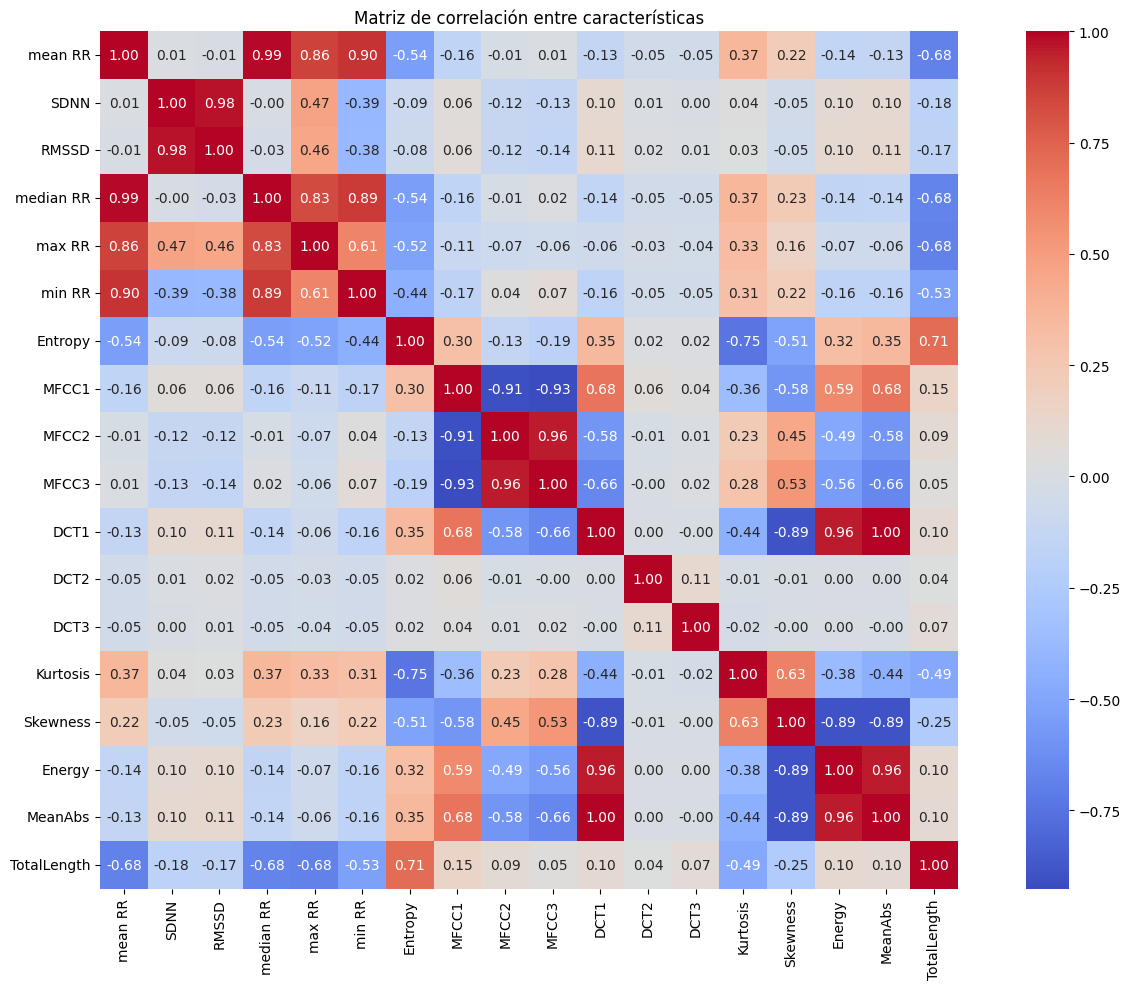

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcula la matriz de correlación para las columnas numéricas
corr = df_final.select_dtypes(include='number').corr()

# Dibuja el mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de correlación entre características')
plt.tight_layout()
plt.show()


In [ ]:
df_final = df_final.drop(columns=['median RR', 'min RR', 'MFCC3', 'MeanAbs', 'DCT1'])


In [ ]:
df_final

,Registros,Estado,mean RR,SDNN,RMSSD,max RR,Entropy,MFCC1,MFCC2,DCT2,DCT3,Kurtosis,Skewness,Energy,TotalLength
0,MUSE_20180111_155758_17000.csv,SB,1083.750000,25.443214,41.672190,1130.0,1.580149,-31.501132,74.667985,-0.114421,-0.046171,38.190823,5.892667,82.883178,21.460954
1,MUSE_20180111_155839_67000.csv,SB,1036.000000,16.613248,20.199010,1064.0,2.333587,-16.275652,86.805282,-0.023981,0.051519,15.410858,3.040627,659.513338,31.460890
2,MUSE_20180111_155859_36000.csv,SB,1079.000000,18.547237,24.773257,1102.0,2.439855,-34.814595,98.553555,0.251187,0.066923,3.507673,1.347407,595.930903,28.550338
3,MUSE_20180111_155907_78000.csv,SB,1071.750000,16.576662,18.807293,1096.0,2.318446,-36.156376,98.570732,-0.015836,-0.028292,8.833689,2.032857,649.779110,27.646357
4,MUSE_20180111_160033_11000.csv,SB,1260.333333,13.170674,20.019990,1272.0,1.273742,-92.011036,107.077165,0.026754,-0.013364,49.194914,6.732622,148.985316,18.560312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9058,MUSE_20180120_123622_77000.csv,ST,532.352941,2.148871,3.427827,536.0,2.787071,31.307734,79.028659,0.002834,0.213764,10.497151,-3.028060,3124.700133,46.439297
9059,MUSE_20180120_123627_02000.csv,ST,530.705882,2.229482,2.828427,536.0,2.359367,-35.185703,102.443341,0.125416,0.011567,16.051814,3.910246,174.179963,45.397043
9060,MUSE_20180120_123702_33000.csv,ST,592.500000,21.522082,8.594572,628.0,2.662956,16.824280,92.164781,0.118457,-0.025968,4.962715,1.378793,909.926612,56.618449
9061,MUSE_20180120_123755_94000.csv,ST,427.619048,1.203170,1.732051,430.0,3.336500,23.222414,96.465621,-0.073294,-0.038224,0.217697,0.791712,1504.414895,75.976729


In [ ]:
df_final.to_csv('ecg_features_final.csv', index=False)


# Construcción de los modelos

### Partición de los datos

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('ecg_features_final.csv')

X = df.drop(columns=['Registros', 'Estado'])
y = df['Estado']

# Codifica las clases como números
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Escala los features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divide en train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)


## Modelo XGBoost

In [ ]:
%pip install xgboost


     -------------------------------------- 150.0/150.0 MB 8.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Programación\Bioseñales\Laboratorio y proyectos\biosignals\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:31:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


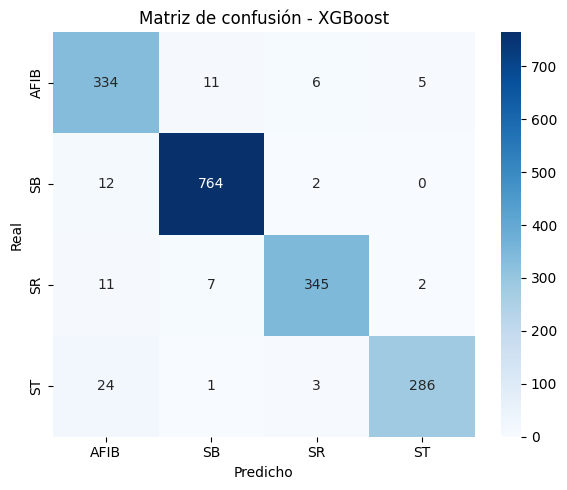

              precision    recall  f1-score   support

        AFIB       0.88      0.94      0.91       356
          SB       0.98      0.98      0.98       778
          SR       0.97      0.95      0.96       365
          ST       0.98      0.91      0.94       314

    accuracy                           0.95      1813
   macro avg       0.95      0.94      0.95      1813
weighted avg       0.96      0.95      0.95      1813



In [ ]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Crea el modelo XGBoost
clf = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=1)

# Entrena
clf.fit(X_train, y_train)

# Predice
y_pred = clf.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de confusión - XGBoost')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred, target_names=le.classes_))


## K-Means

In [ ]:
# Selecciona solo las columnas numéricas
X = df_final.drop(columns=['Registros', 'Estado'])

# Encuentra los índices con NaN
nan_indices = X[X.isna().any(axis=1)].index

# Imprime cuáles registros y clases serán eliminados
if len(nan_indices) > 0:
    print("Registros eliminados por contener NaN:")
    print(df_final.loc[nan_indices, ['Registros', 'Estado']])
else:
    print("No hay filas con NaN.")

# Elimina los registros con NaN en las características
df_no_nan = df_final.drop(index=nan_indices).reset_index(drop=True)
X_no_nan = df_no_nan.drop(columns=['Registros', 'Estado'])


Registros eliminados por contener NaN:
                           Registros Estado
5030  MUSE_20180116_131253_72000.csv   AFIB
5108  MUSE_20180116_173718_14000.csv   AFIB
7742  MUSE_20180112_170004_44000.csv     ST
7743  MUSE_20180112_170005_52000.csv     ST
8056  MUSE_20180113_185325_97000.csv     ST
8084  MUSE_20180114_070744_27000.csv     ST


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. Elimina filas con NaN y muestra cuáles elimina
X = df_final.drop(columns=['Registros', 'Estado'])
nan_indices = X[X.isna().any(axis=1)].index

if len(nan_indices) > 0:
    print("Registros eliminados por contener NaN:")
    print(df_final.loc[nan_indices, ['Registros', 'Estado']])
else:
    print("No hay filas con NaN.")

df_no_nan = df_final.drop(index=nan_indices).reset_index(drop=True)
X_no_nan = df_no_nan.drop(columns=['Registros', 'Estado'])

# 2. Aplica K-means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=1, n_init=20)
clusters = kmeans.fit_predict(X_no_nan)

# 3. Agrega los clusters al DataFrame limpio
df_no_nan['cluster'] = clusters

# 4. Tabla de conteo cruzado: clusters vs clases reales
print("\nTabla de clusters vs. clases reales:")
print(pd.crosstab(df_no_nan['Estado'], df_no_nan['cluster'], rownames=['Clase real'], colnames=['Cluster asignado']))

# 5. (Opcional) Índice de Rand ajustado
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df_no_nan['Estado'], df_no_nan['cluster'])
print(f"\nAdjusted Rand Index: {ari:.2f}")


Registros eliminados por contener NaN:
                           Registros Estado
5030  MUSE_20180116_131253_72000.csv   AFIB
5108  MUSE_20180116_173718_14000.csv   AFIB
7742  MUSE_20180112_170004_44000.csv     ST
7743  MUSE_20180112_170005_52000.csv     ST
8056  MUSE_20180113_185325_97000.csv     ST
8084  MUSE_20180114_070744_27000.csv     ST

Tabla de clusters vs. clases reales:
Cluster asignado     0    1     2    3
Clase real                            
AFIB               458  130   855  335
SB                3276  118    12  483
SR                 507   62   996  261
ST                   2  134  1259  169

Adjusted Rand Index: 0.35


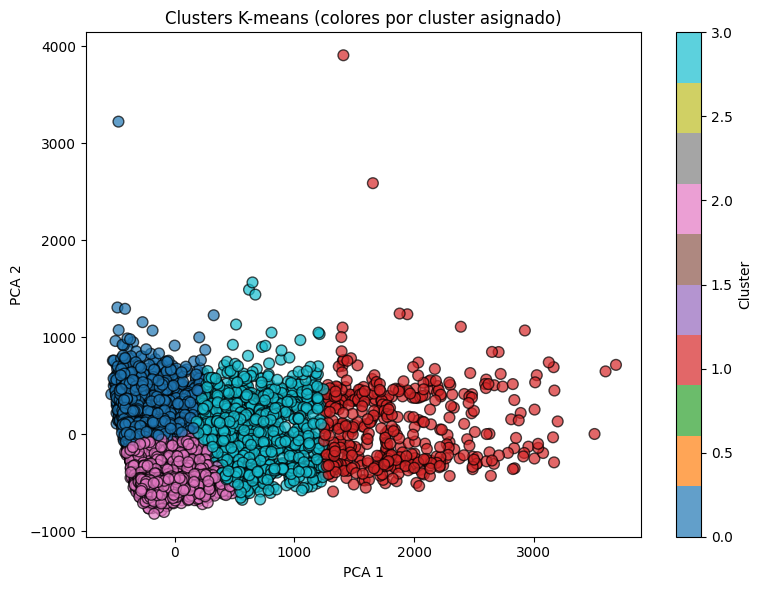

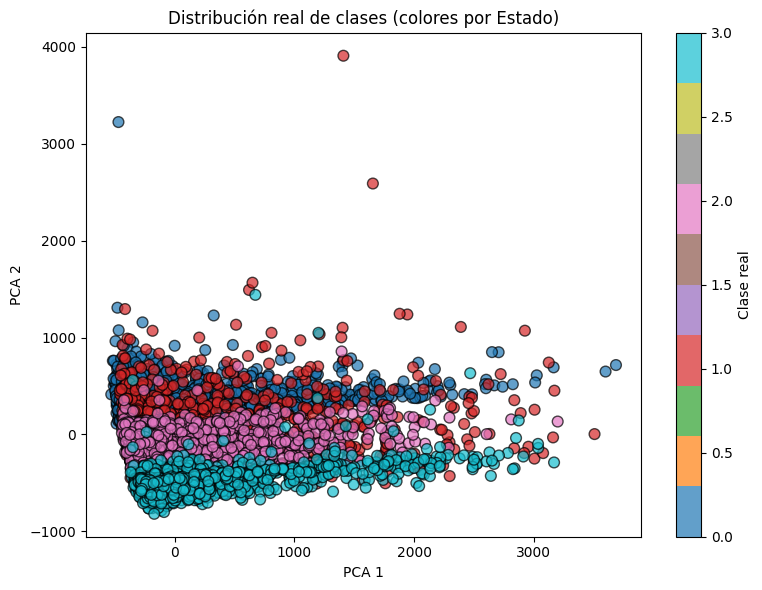

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Supón que ya tienes X_no_nan (solo features) y df_no_nan (con columna 'cluster' y 'Estado')

# Aplica PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_no_nan)

# Dibuja los clusters encontrados por K-means
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=df_no_nan['cluster'], cmap='tab10', alpha=0.7, edgecolor='k', s=60
)
plt.title("Clusters K-means (colores por cluster asignado)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# (Opcional) Visualiza clases reales en colores
plt.figure(figsize=(8,6))
scatter2 = plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=pd.factorize(df_no_nan['Estado'])[0], cmap='tab10', alpha=0.7, edgecolor='k', s=60
)
plt.title("Distribución real de clases (colores por Estado)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter2, label='Clase real')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

ctab = pd.crosstab(df_no_nan['Estado'], df_no_nan['cluster'], rownames=['Clase real'], colnames=['Cluster asignado'])


In [ ]:
# Supón que tu crosstab ya está en la variable ctab (DataFrame)
import numpy as np

# Calcula el número de aciertos: suma la máxima frecuencia (clase mayoritaria) de cada cluster
aciertos = 0
for cluster in ctab.columns:
    aciertos += ctab[cluster].max()

total = ctab.values.sum()
accuracy_clusters = aciertos / total
error_clusters = 1 - accuracy_clusters

print(f"Accuracy de clusters (mejor mapeo): {accuracy_clusters:.2f}")
print(f"Tasa de error de clusterización: {error_clusters:.2f}")

# (Opcional) Mostrar el mapeo cluster->clase
print("\nAsignación de cluster a clase más frecuente:")
for cluster in ctab.columns:
    clase_mayoritaria = ctab[cluster].idxmax()
    print(f"Cluster {cluster}: {clase_mayoritaria}")


Accuracy de clusters (mejor mapeo): 0.57
Tasa de error de clusterización: 0.43

Asignación de cluster a clase más frecuente:
Cluster 0: SB
Cluster 1: ST
Cluster 2: ST
Cluster 3: SB


## SVM

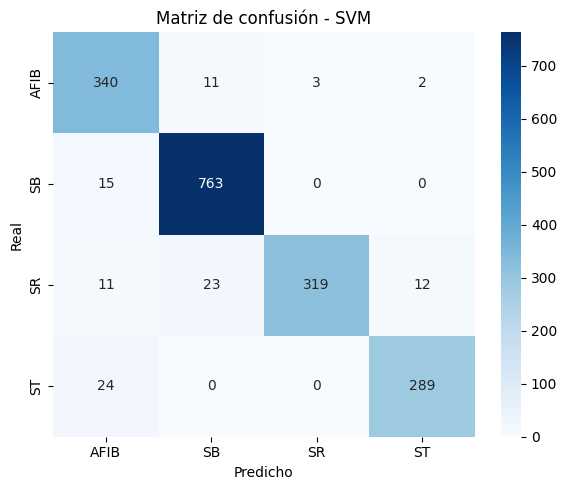

              precision    recall  f1-score   support

        AFIB       0.87      0.96      0.91       356
          SB       0.96      0.98      0.97       778
          SR       0.99      0.87      0.93       365
          ST       0.95      0.92      0.94       313

    accuracy                           0.94      1812
   macro avg       0.94      0.93      0.94      1812
weighted avg       0.95      0.94      0.94      1812



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Usa df_no_nan (ya sin NaN)
X = df_no_nan.drop(columns=['Registros', 'Estado', 'cluster'], errors='ignore')  # Quita cluster si existe
y = df_no_nan['Estado']

# Codifica las etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Escala las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divide en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Entrena SVM
clf = SVC(kernel='rbf', C=1, gamma='scale', probability=False, random_state=42)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de confusión - SVM')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred, target_names=le.classes_))


# RED NEURONAL

In [ ]:

# 2. Leer datos
import pandas as pd

df = pd.read_csv('ecg_features_final.csv')

# 3. Mapear etiquetas de texto a números
# Modifica según tus necesidades (por ejemplo: SB ≈ ST o la excluyes)
label_map = {
    'SR': 0,
    'AFIB': 1,
    'ST': 2,
    'SB': 3  # <- puedes mapear SB a ST si representan taquicardia sinusal
}
df['Estado'] = df['Estado'].map(label_map)

# 4. Eliminar registros con etiquetas desconocidas (NaN tras map)
df = df.dropna(subset=['Estado'])

# 5. Separar características y etiquetas
features = ['mean RR','SDNN','RMSSD','max RR','Entropy','MFCC1','MFCC2',
            'DCT2','DCT3','Kurtosis','Skewness','Energy','TotalLength']
X = df[features].values
y = df['Estado'].astype(int).values

# 5b. Eliminar registros con valores NaN en las características
df = df.dropna(subset=features)
X = df[features].values
y = df['Estado'].astype(int).values


# 6. Escalar características
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Dividir datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# 8. Balancear con SMOTE
!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

**4. Clasificación de cuatro patologías cardiacas**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, MaxPooling1D, Flatten
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras.layers import BatchNormalization

# Arquitecturas
def build_model_1(input_dim):
    return Sequential([
    Dense(256, activation='relu', input_dim=input_dim),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

def build_model_2(input_dim):
    return Sequential([
    Input(shape=(input_dim, 1)),  # reshape: X.reshape(-1, 13, 1)
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

def build_model_3(input_dim):
    return Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax')
    ])

# Entrenar y evaluar
def train_and_evaluate(model_fn, name):
    print(f"\nEntrenando: {name}")
    model = model_fn(X_train_bal.shape[1])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train_bal, y_train_bal, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} - Accuracy en test: {acc:.4f}")

    y_pred = model.predict(X_test).argmax(axis=1)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["SR", "AFIB", "ST", "SB"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["SR", "AFIB", "ST", "SB"]))


Entrenando: Arquitectura 1 (BatchNorm)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arquitectura 1 (BatchNorm) - Accuracy en test: 0.9592
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


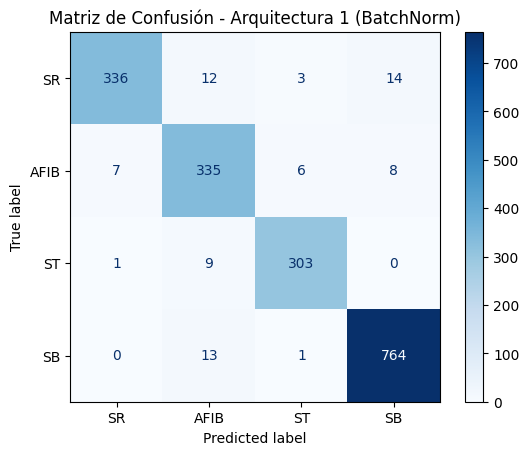

              precision    recall  f1-score   support

          SR       0.98      0.92      0.95       365
        AFIB       0.91      0.94      0.92       356
          ST       0.97      0.97      0.97       313
          SB       0.97      0.98      0.98       778

    accuracy                           0.96      1812
   macro avg       0.96      0.95      0.95      1812
weighted avg       0.96      0.96      0.96      1812


Entrenando: Arquitectura 2 (CNN 1D)
Arquitectura 2 (CNN 1D) - Accuracy en test: 0.9608
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


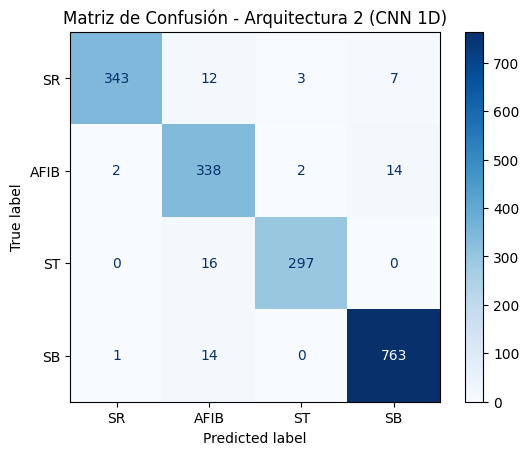

              precision    recall  f1-score   support

          SR       0.99      0.94      0.96       365
        AFIB       0.89      0.95      0.92       356
          ST       0.98      0.95      0.97       313
          SB       0.97      0.98      0.98       778

    accuracy                           0.96      1812
   macro avg       0.96      0.95      0.96      1812
weighted avg       0.96      0.96      0.96      1812


Entrenando: Arquitectura 3 (Dropout Profunda)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arquitectura 3 (Dropout Profunda) - Accuracy en test: 0.9564
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


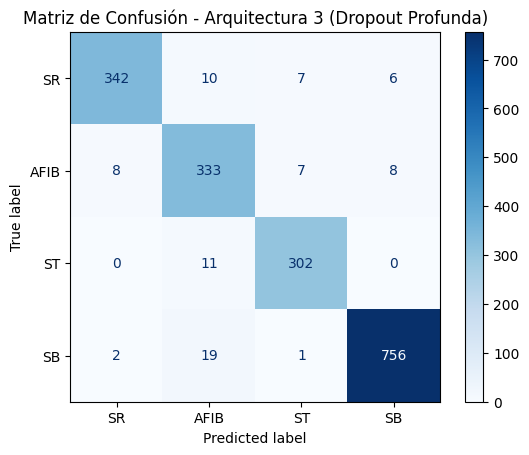

              precision    recall  f1-score   support

          SR       0.97      0.94      0.95       365
        AFIB       0.89      0.94      0.91       356
          ST       0.95      0.96      0.96       313
          SB       0.98      0.97      0.98       778

    accuracy                           0.96      1812
   macro avg       0.95      0.95      0.95      1812
weighted avg       0.96      0.96      0.96      1812


📊 Comparación de modelos:
                              Modelo  Accuracy  Precision  Recall  F1-Score
0         Arquitectura 1 (BatchNorm)    0.9592     0.9597  0.9592    0.9592
1            Arquitectura 2 (CNN 1D)    0.9608     0.9622  0.9608    0.9611
2  Arquitectura 3 (Dropout Profunda)    0.9564     0.9572  0.9564    0.9566


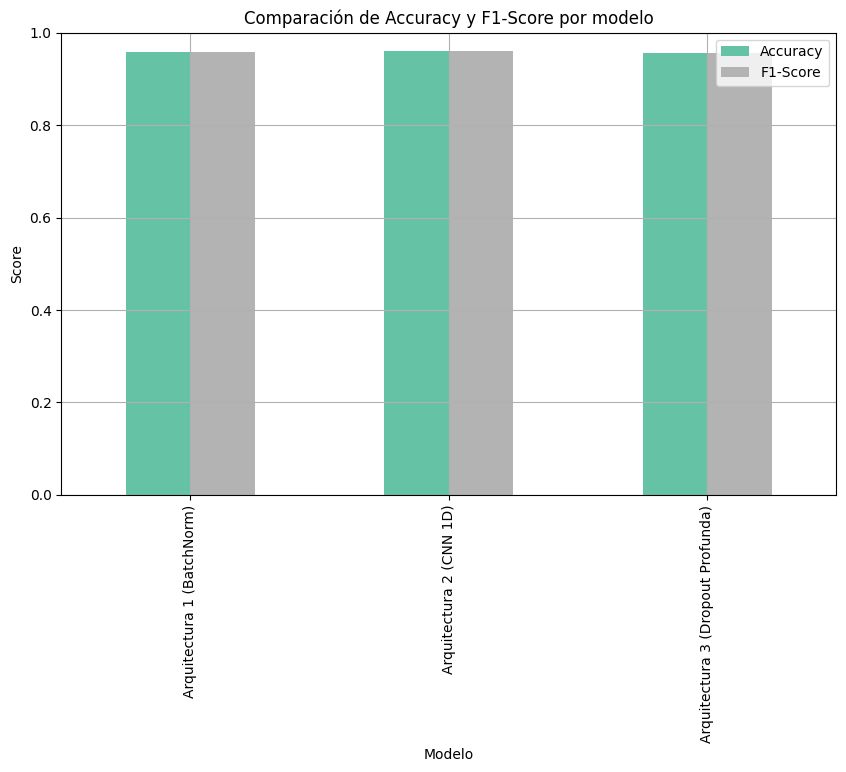

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Lista para guardar resultados
results = []

def train_and_evaluate(model_fn, name):
    print(f"\nEntrenando: {name}")
    model = model_fn(X_train_bal.shape[1])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train_bal, y_train_bal, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} - Accuracy en test: {acc:.4f}")

    y_pred = model.predict(X_test).argmax(axis=1)

    # Métricas
    acc_score = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Modelo': name,
        'Accuracy': acc_score,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["SR", "AFIB", "ST", "SB"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["SR", "AFIB", "ST", "SB"]))

# Ejecutar y comparar
train_and_evaluate(build_model_1, "Arquitectura 1 (BatchNorm)")
train_and_evaluate(build_model_2, "Arquitectura 2 (CNN 1D)")
train_and_evaluate(build_model_3, "Arquitectura 3 (Dropout Profunda)")

# Mostrar resultados comparativos
df_results = pd.DataFrame(results)
print("\n📊 Comparación de modelos:")
print(df_results.round(4))

# Gráfico opcional
df_results.set_index('Modelo')[['Accuracy', 'F1-Score']].plot.bar(figsize=(10, 6), colormap='Set2')
plt.title('Comparación de Accuracy y F1-Score por modelo')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True)
plt.show()


**5. Clasificación de dos patologías cardiacas**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Leer datos
df = pd.read_csv('ecg_features_final.csv')

# 2. Filtrar solo las clases AFIB y ST
df = df[df['Estado'].isin(['AFIB', 'ST'])]

# 3. Mapear etiquetas: AFIB → 0, ST → 1
label_map = {
    'AFIB': 0,
    'ST': 1
}
df['Estado'] = df['Estado'].map(label_map)

# 4. Eliminar registros con valores NaN en características
features = ['mean RR','SDNN','RMSSD','max RR','Entropy','MFCC1','MFCC2',
            'DCT2','DCT3','Kurtosis','Skewness','Energy','TotalLength']
df = df.dropna(subset=features)

# 5. Separar características y etiquetas
X = df[features].values
y = df['Estado'].astype(int).values

# 6. Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 8. Balancear clases con SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, MaxPooling1D, Flatten, BatchNormalization

# Modelo 1: MLP con BatchNorm
def build_model_1(input_dim):
    return Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

# Modelo 2: CNN 1D
def build_model_2(input_dim):
    return Sequential([
        Input(shape=(input_dim, 1)),  # reshape: X.reshape(-1, input_dim, 1)
        Conv1D(32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

# Modelo 3: MLP con Dropout profundo
def build_model_3(input_dim):
    return Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])



🔧 Entrenando: Arquitectura 1 (BatchNorm)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Arquitectura 1 (BatchNorm) - Accuracy en test: 0.9611
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


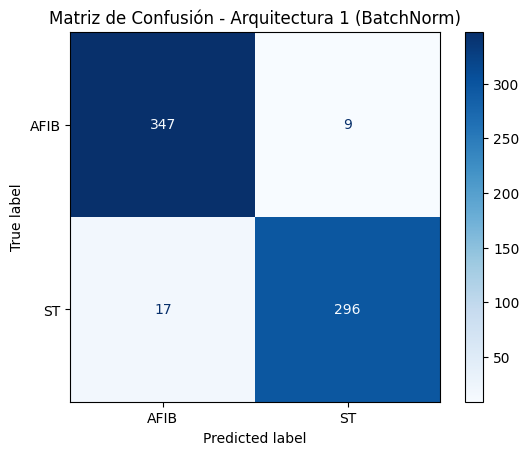

              precision    recall  f1-score   support

        AFIB       0.95      0.97      0.96       356
          ST       0.97      0.95      0.96       313

    accuracy                           0.96       669
   macro avg       0.96      0.96      0.96       669
weighted avg       0.96      0.96      0.96       669


🔧 Entrenando: Arquitectura 2 (CNN 1D)
✅ Arquitectura 2 (CNN 1D) - Accuracy en test: 0.9626
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


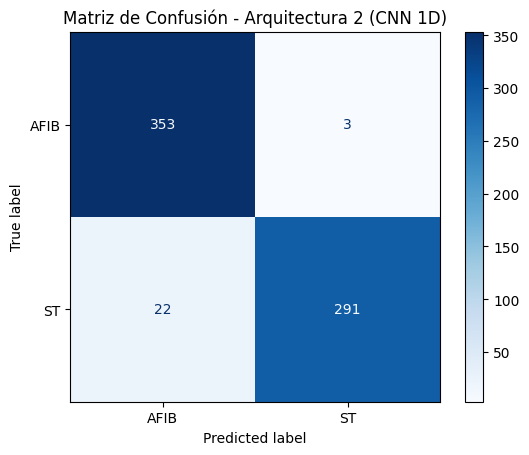

              precision    recall  f1-score   support

        AFIB       0.94      0.99      0.97       356
          ST       0.99      0.93      0.96       313

    accuracy                           0.96       669
   macro avg       0.97      0.96      0.96       669
weighted avg       0.96      0.96      0.96       669


🔧 Entrenando: Arquitectura 3 (Dropout Profunda)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Arquitectura 3 (Dropout Profunda) - Accuracy en test: 0.9686
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


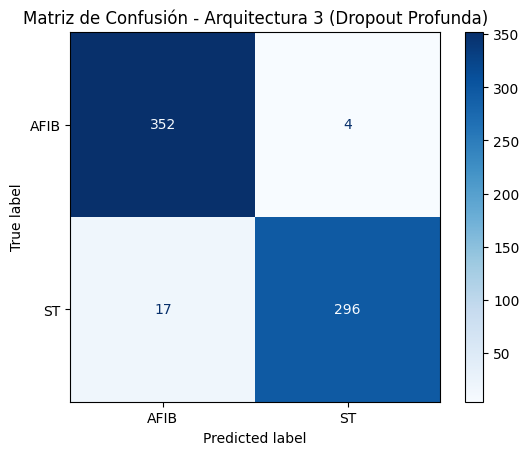

              precision    recall  f1-score   support

        AFIB       0.95      0.99      0.97       356
          ST       0.99      0.95      0.97       313

    accuracy                           0.97       669
   macro avg       0.97      0.97      0.97       669
weighted avg       0.97      0.97      0.97       669


📊 Comparación de modelos:
                              Modelo  Accuracy  Precision  Recall  F1-Score
0         Arquitectura 1 (BatchNorm)    0.9611     0.9705  0.9457    0.9579
1            Arquitectura 2 (CNN 1D)    0.9626     0.9898  0.9297    0.9588
2  Arquitectura 3 (Dropout Profunda)    0.9686     0.9867  0.9457    0.9657


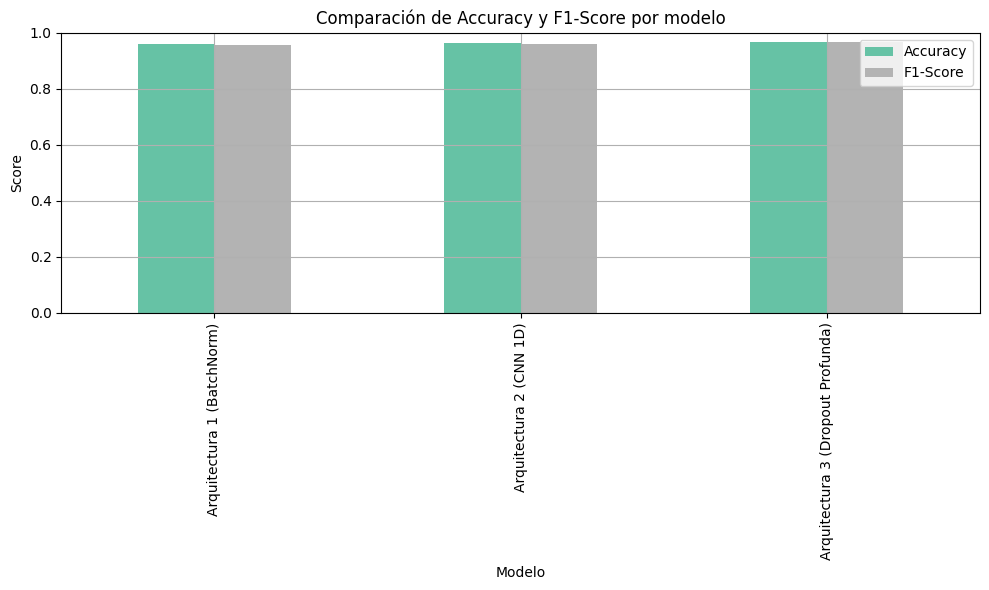

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import numpy as np # Import numpy for reshaping

# Lista para guardar resultados
results = []

def train_and_evaluate(model_fn, name, X_train, y_train, X_test, y_test):
    print(f"\n🔧 Entrenando: {name}")
    # Check if the model is CNN and reshape data accordingly
    input_dim = X_train.shape[1]
    if name == "Arquitectura 2 (CNN 1D)":
        X_train = X_train.reshape(-1, input_dim, 1)
        X_test = X_test.reshape(-1, input_dim, 1)
        model = model_fn(input_dim)
    else:
        model = model_fn(input_dim)


    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

    # Evaluar en test
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {name} - Accuracy en test: {acc:.4f}")

    # Predicciones binarizadas
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Métricas
    acc_score = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Modelo': name,
        'Accuracy': acc_score,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["AFIB", "ST"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["AFIB", "ST"]))

# Ejecutar evaluaciones

train_and_evaluate(build_model_1, "Arquitectura 1 (BatchNorm)", X_train_bal, y_train_bal, X_test, y_test)

train_and_evaluate(build_model_2, "Arquitectura 2 (CNN 1D)", X_train_bal, y_train_bal, X_test, y_test)
train_and_evaluate(build_model_3, "Arquitectura 3 (Dropout Profunda)", X_train_bal, y_train_bal, X_test, y_test)

# Comparación final de resultados

df_results = pd.DataFrame(results)
print("\n📊 Comparación de modelos:")
print(df_results.round(4))

# Gráfico comparativo
df_results.set_index('Modelo')[['Accuracy', 'F1-Score']].plot.bar(figsize=(10, 6), colormap='Set2')
plt.title('Comparación de Accuracy y F1-Score por modelo')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()